### Load libraries

##### The next code block is necessary to get the data. To set it up follow these steps:
1. Sign up to [Roboflow](https://www.roboflow.com)
2. Get an api key from [Roboflow api page](https://app.roboflow.com/settings/api)
3. Go to Kaggle secret and add the key as **roboflow_key**

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
roboflow_key = user_secrets.get_secret("roboflow_key")

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=roboflow_key)
project = rf.workspace("somework").project("chess-zn1zf")
version = project.version(1)
dataset = version.download("yolo26")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, w


Extracting Dataset Version Zip to Chess-1 in yolo26:: 100%|██████████| 1130/1130 [00:00<00:00, 11041.14it/s]


In [3]:
from glob import glob
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import time
import random

In [4]:
epochs = 40
plt.style.use("dark_background")

In [5]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Create model

In [6]:
model = YOLO("yolo26n.pt")


0: 320x320 1 vase, 17.2ms
1: 320x320 1 vase, 17.2ms
2: 320x320 1 dining table, 17.2ms
3: 320x320 1 vase, 17.2ms
Speed: 1.7ms preprocess, 17.2ms inference, 8.6ms postprocess per image at shape (1, 3, 320, 320)


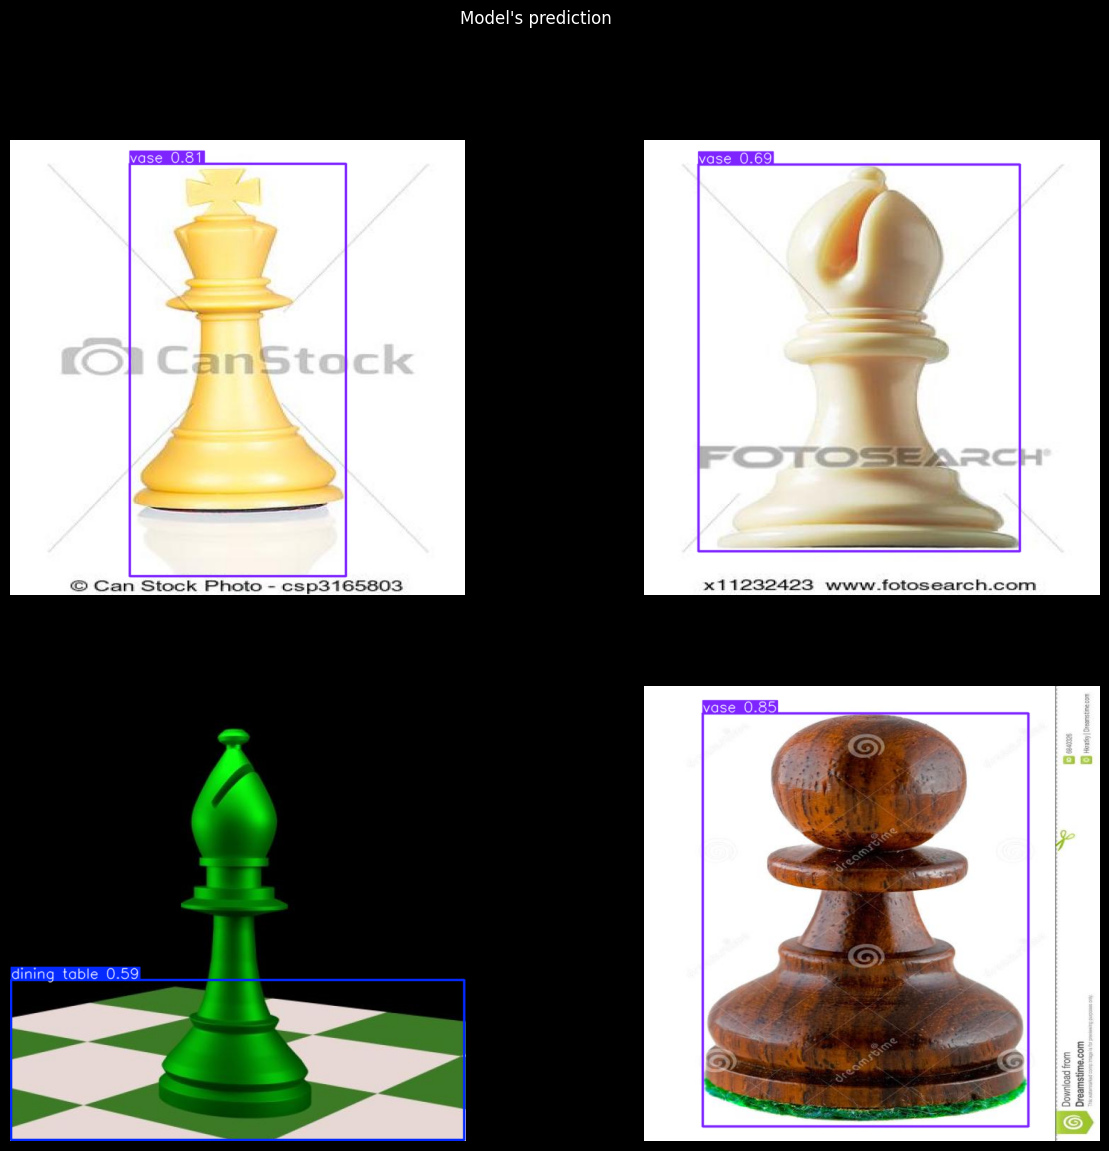

In [7]:
# test without training
results = model.predict(glob("Chess-1/test/images/*.jpg")[:4], imgsz=320)

plt.figure(figsize=(15, 13))
for i, res in enumerate(results):
   ax = plt.subplot(2, 2, i+1)
   img = res.plot()

   ax.imshow(img[:, :, ::-1])
   ax.axis("off")

plt.suptitle("Model's prediction")
plt.show()

### Train the model

In [8]:
model.train(data="Chess-1/data.yaml", batch=8, epochs=epochs, imgsz=320, device=[-1, -1])

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [1, 0]
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:1 (Tesla T4, 14913MiB)
                                                      CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Chess-1/data.yaml, degrees=0.0, deterministic=True, device=1,0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

### Get the best weight's model and test

In [9]:
best_model = YOLO("runs/detect/train/weights/best.pt")


0: 320x320 1 king, 9.1ms
1: 320x320 1 bishop, 9.1ms
2: 320x320 1 bishop, 9.1ms
3: 320x320 1 pawn, 9.1ms
4: 320x320 1 bishop, 9.1ms
5: 320x320 1 pawn, 9.1ms
Speed: 0.7ms preprocess, 9.1ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)


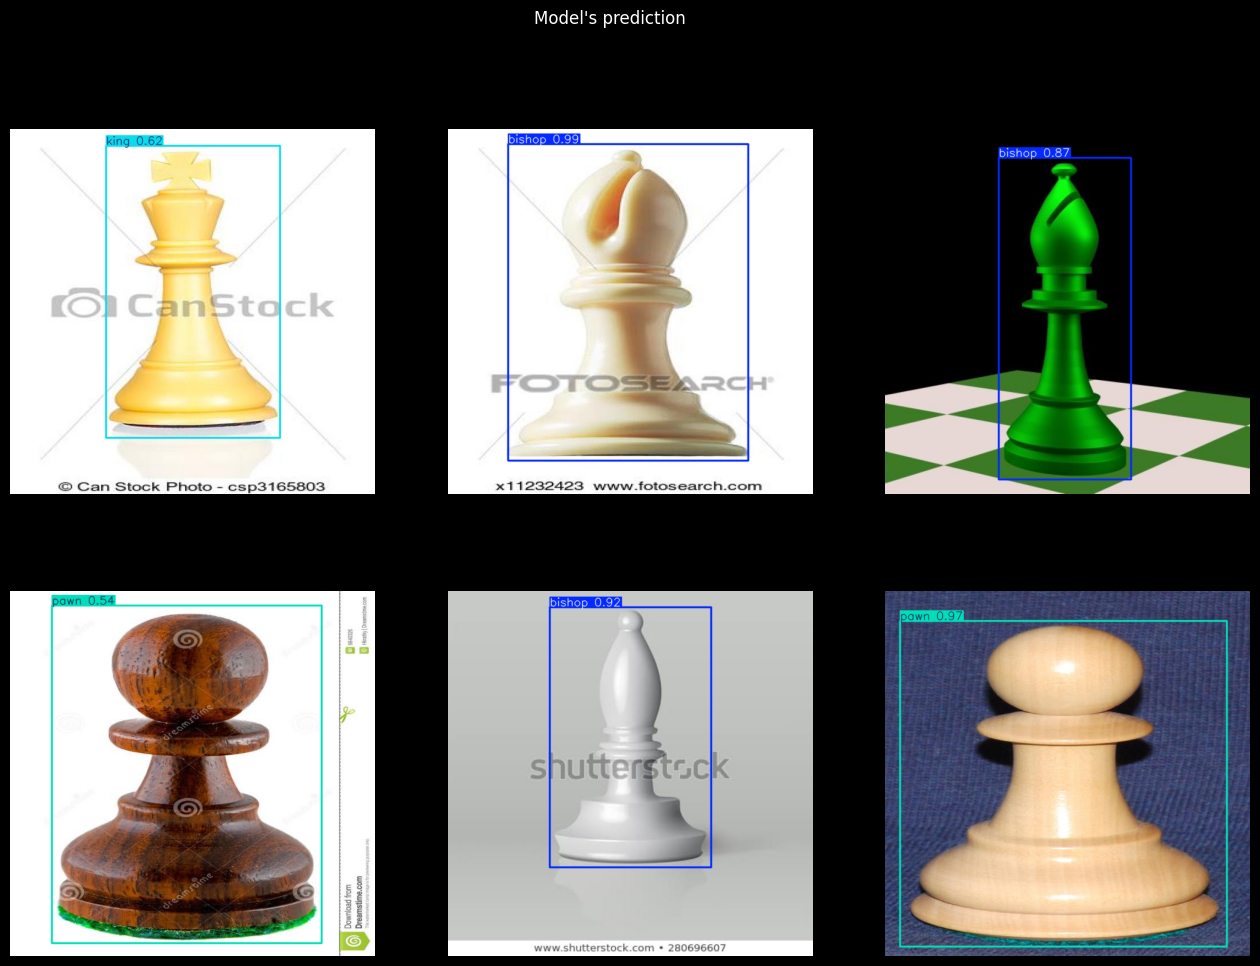

In [10]:
results = best_model.predict(glob("Chess-1/test/images/*.jpg")[:6], imgsz=320)


plt.figure(figsize=(16, 11))
for i, res in enumerate(results):
   ax = plt.subplot(2, 3, i+1)
   img = res.plot()

   ax.imshow(img[:, :, ::-1])
   ax.axis("off")

plt.suptitle("Model's prediction")
plt.show()

In [11]:
urls = [
  "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6f/ChessSet.jpg/500px-ChessSet.jpg",
  "https://upload.wikimedia.org/wikipedia/commons/thumb/3/30/ChessStartingPosition.jpg/500px-ChessStartingPosition.jpg",
  "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Chess_piece_-_White_pawn.JPG/330px-Chess_piece_-_White_pawn.JPG",
  "https://upload.wikimedia.org/wikipedia/commons/thumb/7/7e/Chess_piece_-_Black_pawn.JPG/330px-Chess_piece_-_Black_pawn.JPG",
  "https://upload.wikimedia.org/wikipedia/commons/thumb/b/ba/Chess_piece_-_Black_bishop.JPG/330px-Chess_piece_-_Black_bishop.JPG",
  "https://upload.wikimedia.org/wikipedia/commons/thumb/b/ba/Chess_piece_-_White_bishop.JPG/330px-Chess_piece_-_White_bishop.JPG"
]
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1"
}

images = []
for i, url in enumerate(urls, 1):
  try:
     res = requests.get(url, headers=headers)
     img = BytesIO(res.content)
     img = Image.open(img)
     images.append(img)
     # Add a randomized delay between 3 and 5 seconds
     time.sleep(random.uniform(3, 5))
  except Exception as e:
      print(f"Error in {i}th image: {e}")
      continue

Error in 6th image: cannot identify image file <_io.BytesIO object at 0x7b9e49d72570>



0: 320x320 1 bishop, 1 king, 2 queens, 10.8ms
1: 320x320 5 bishops, 7 kings, 66 pawns, 1 queen, 7 rooks, 10.8ms
2: 320x320 1 pawn, 10.8ms
3: 320x320 1 pawn, 10.8ms
4: 320x320 1 bishop, 10.8ms
Speed: 0.6ms preprocess, 10.8ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)


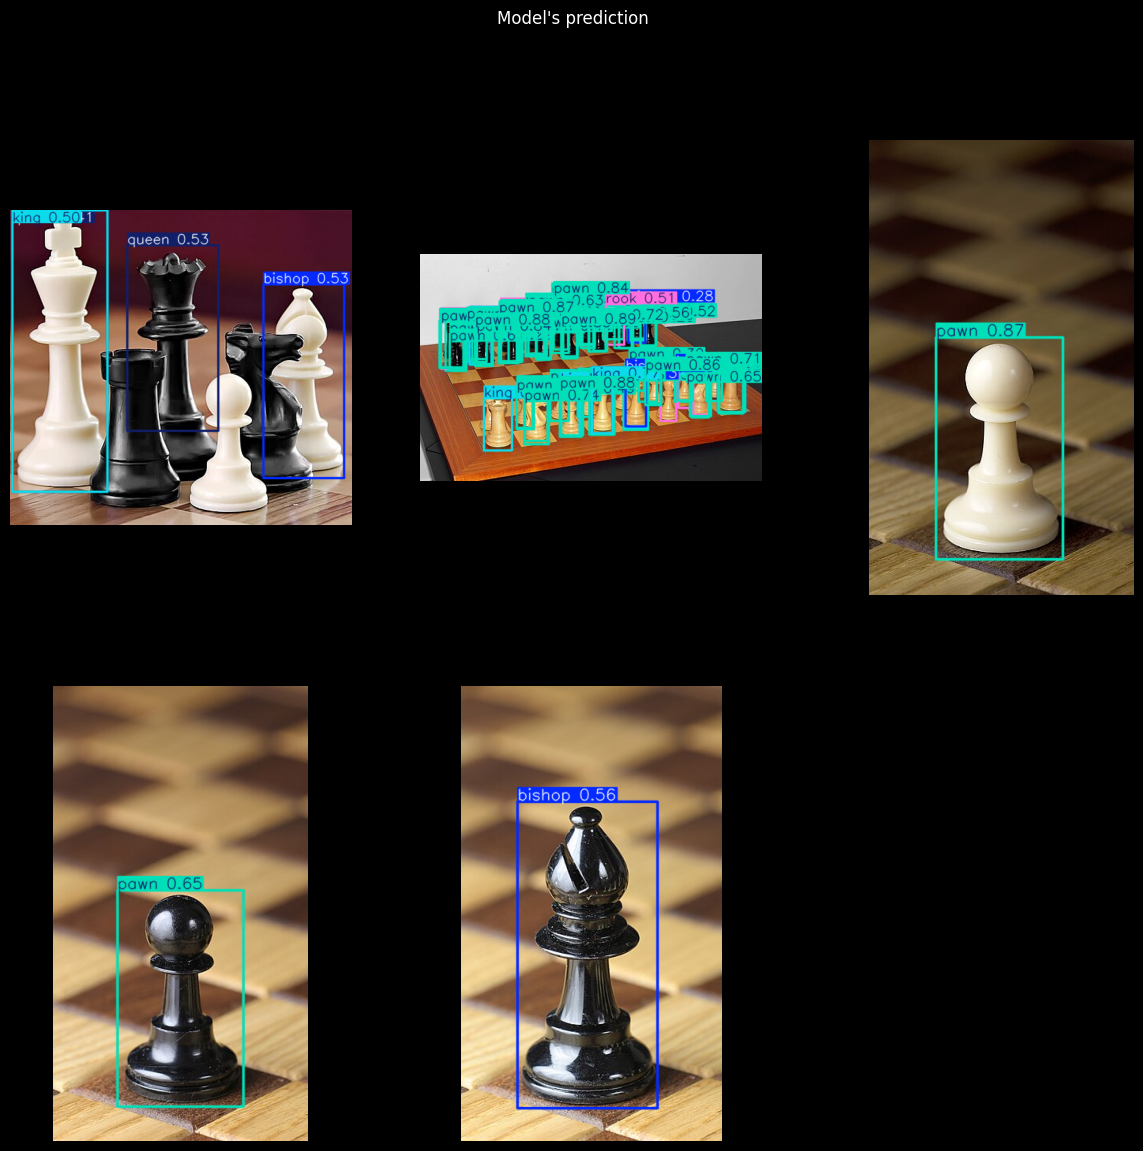

In [12]:
results = best_model.predict(images, imgsz=320)

plt.figure(figsize=(15, 13))
for i, res in enumerate(results):
   ax = plt.subplot(2, 3, i+1)
   img = res.plot()

   ax.imshow(img[:, :, ::-1])
   ax.axis("off")

plt.suptitle("Model's prediction")
plt.show()

In [13]:
result = best_model.val(verbose=False)

for res in result.summary():
    for k, v in res.items():
        print(f"\t{k}: {v}")
    print("-"*40)

Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 745.2±184.6 MB/s, size: 19.1 KB)
val: Scanning /kaggle/working/Chess-1/valid/labels.cache... 112 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.8it/s 1.2s
                   all        112        127      0.878      0.733      0.863      0.752
Speed: 0.3ms preprocess, 2.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
	Class: bishop
	Images: 20
	Instances: 21
	Box-P: 0.79728
	Box-R: 0.71429
	Box-F1: 0.75351
	mAP50: 0.83375
	mAP50-95: 0.68912
----------------------------------------
	Class: king
	Images: 15
	Instances: 16
	Box-P: 0.87924
	Box-R: 0.8125
	Box-F1: 0.84456
	mAP50: 0.89102
	mAP50-95: 0.71889
----------------------------------------
	Class: knight
	Imag